In [1]:
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.io import fits
from astropy.visualization import simple_norm
from spectral_cube import SpectralCube as sc
from tqdm import trange

from pybaselines import Baseline
from pybaselines.utils import gaussian, relative_difference
from pybaselines._banded_utils import PenalizedSystem
from pybaselines._weighting import _arpls

from joblib import Parallel, delayed
from functools import partial

from pybaselines.utils import ParameterWarning
import warnings

# 屏蔽所有 ParameterWarning
warnings.filterwarnings("ignore")

%matplotlib widget

In [2]:
# Define RA ranges and signs
pattern = "./North/Combined/CRAFTS_RA{ra}_DEC24_33.fits"
ra_ranges = ["10_30", "30_50", "50_70", "70_90"]
ra_i = 3  # Change this index to select different RA ranges
ra = ra_ranges[ra_i]

# Original file
file = pattern.format(ra=ra)

# Baseline corrected file
corrected_path = "./North/Baseline Corrected/"
corrected_name = f"CRAFTS_RA{ra}_DEC24_33"

corrected_file_neg = f"{corrected_path}{corrected_name}_cor_-.fits"
corrected_file_pos = f"{corrected_path}{corrected_name}_cor_+.fits"

print(f"Original file: {file}")
print(f"neg corrected file: {corrected_file_neg}")
print(f"pos corrected file: {corrected_file_pos}")

Original file: ./North/Combined/CRAFTS_RA70_90_DEC24_33.fits
neg corrected file: ./North/Baseline Corrected/CRAFTS_RA70_90_DEC24_33_cor_-.fits
pos corrected file: ./North/Baseline Corrected/CRAFTS_RA70_90_DEC24_33_cor_+.fits


In [3]:
cube = sc.read(file)

data = cube.unmasked_data[:, :, :].value
data[np.isnan(data)] = 0

n_v, n_y, n_x = data.shape

velocities = cube.spectral_axis.value
cube

SpectralCube with shape=(5962, 364, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:    70.012500 deg:   89.987500 deg
 n_y:    364  type_y: DEC--CAR  unit_y: deg    range:    24.187500 deg:   33.262500 deg
 n_s:   5962  type_s: VRAD      unit_s: m / s  range:  -599897.172 m / s:  599954.336 m / s

In [4]:
def masked_arpls(y, mask=None, lam=1e8, diff_order=2, tol=1e-3, max_iter=50, weights=None):
    """A mask-aware version of the arpls algorithm."""
    len_y = len(y)
    if mask is None:
        mask = np.ones(len_y, dtype=bool)
        y_fit = y
    else:
        y_fit = 1 * y  # don't want to override the input y, so make a copy
        y_fit[~mask] = 0  # cover that case of nan values in y since 0 * nan = nan rather than 0
    if weights is None:
        weights = np.ones(len_y)
    else:
        weights = 1 * weights  # don't want to override the input weights, so make a copy
    weights[~mask] = 0
    whittaker_system = PenalizedSystem(len(y), lam=lam, diff_order=diff_order)
    for _ in range(max_iter):
        baseline = whittaker_system.solve(
            whittaker_system.add_diagonal(weights), weights * y_fit,
        )
        # need to ignore the problem regions in y since they would otherwise affect
        # the arpls weighting; could alternatively do:
        # _arpls(np.interp(x, x[mask], y[mask]), baseline) to approximate
        # the y-values, but it leads to a slightly different result
        calc_weights, exit_early = _arpls(y[mask], baseline[mask])
        if exit_early:
            break
        new_weights = np.zeros(len_y)
        new_weights[mask] = calc_weights
        if relative_difference(weights, new_weights) < tol:
            break
        weights = new_weights
    return baseline


In [5]:
from rotation_model_numpy import calc_v_dev
from astropy.coordinates import SkyCoord

def pix_to_galactic_l_b(celestial_wcs, xpix, ypix):
    lonlat = celestial_wcs.all_pix2world(xpix, ypix, 0)
    ctypes = celestial_wcs.wcs.ctype
    c0 = ctypes[0].upper()
    if "RA" in c0 or "DEC" in c0:
        sc = SkyCoord(ra=lonlat[0] * u.deg, dec=lonlat[1] * u.deg, frame="fk5")
        gal = sc.galactic
        return gal.l.deg, gal.b.deg
    else:
        return lonlat[0], lonlat[1]

In [6]:
wcs = cube.wcs
ny, nx = data.shape[-2], data.shape[-1]
vel_axis = cube.spectral_axis.value
nv = len(vel_axis)

i_grid, j_grid = np.meshgrid(np.arange(nx), np.arange(ny), indexing='ij')

l_deg, b_deg = pix_to_galactic_l_b(wcs.celestial, i_grid, j_grid)

v_max, v_min = calc_v_dev(l_deg, b_deg, model="poly", v_dev=30)

vmax_map = v_max.T
vmin_map = v_min.T

pos_mask = vel_axis[:, None, None] > vmax_map[None, :, :]
neg_mask = vel_axis[:, None, None] < vmin_map[None, :, :]

# 这是 v_dev > 30 区域
baseline_mask = pos_mask | neg_mask

In [7]:
# 拉平成行谱
dataset = data.transpose(1, 2, 0).reshape(n_y * n_x, n_v)  # shape (480000, 5962)
baseline_mask_set = baseline_mask.reshape(n_v, n_y * n_x).T  # shape (480000, 5962)

In [8]:
baselines = np.empty_like(dataset)  # shape (480000, 5962)

# 并行计算
results = Parallel(n_jobs=-1, backend="loky", return_as="generator", verbose=5)(
    delayed(masked_arpls)(dataset[i], baseline_mask_set[i]) for i in range(len(dataset))
)

for i, baseline in enumerate(results):
    baselines[i] = baseline

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
/tmp/ipykernel_241732/1003879514.py:24: ParameterWarning: almost all baseline points are below the data, indicating that "tol" is too low and/or "max_iter" is too high
/tmp/ipykernel_241732/1003879514.py:24: ParameterWarning: almost all baseline points are below the data, indicating that "tol" is too low and/or "max_iter" is too high
/tmp/ipykernel_241732/1003879514.py:24: ParameterWarning: almost all baseline points are below the data, indicating that "tol" is too low and/or "max_iter" is too high
/tmp/ipykernel_241732/1003879514.py:24: ParameterWarning: almost all baseline points are below the data, indicating that "tol" is too low and/or "max_iter" is too high
/tmp/ipykernel_241732/1003879514.py:24: ParameterWarning: almost all baseline points are below the data, indicating that "tol" is too low and/or "max_iter" is too high
/tmp/ipykernel_241732/1003879514.py:24: ParameterWarning: almost all baseline point

In [9]:
baselines = baselines.T.reshape(n_v, n_y, n_x)
baselines << u.K
baselines_cube = sc(data=baselines, wcs=cube.wcs)
baselines_cube

corrected = data - baselines
corrected << u.K
corrected_cube = sc(data=corrected, wcs=cube.wcs)
corrected_cube

SpectralCube with shape=(5962, 364, 800):
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:    70.012500 deg:   89.987500 deg
 n_y:    364  type_y: DEC--CAR  unit_y: deg    range:    24.187500 deg:   33.262500 deg
 n_s:   5962  type_s: VRAD      unit_s: m / s  range:  -599897.172 m / s:  599954.336 m / s

In [10]:
vmax_global = np.min(vmax_map)
max_v = np.max(vel_axis)

min_v = np.min(vel_axis)
vmin_global = np.max(vmin_map)

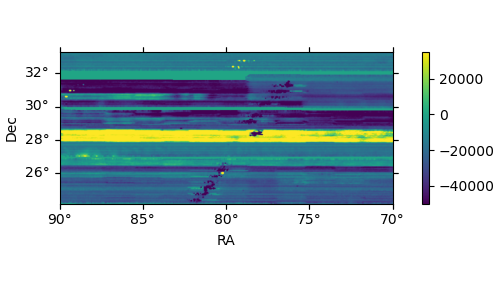

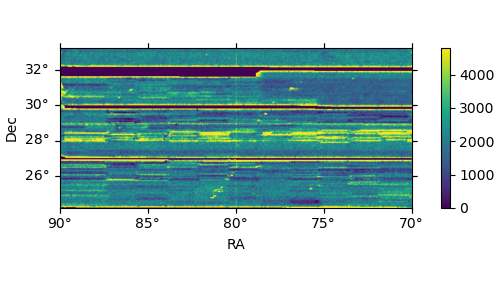

In [11]:
def displayimage(cube, region=None):
    img = cube.moment(order=0).value  # moment 0
    fig, ax = plt.subplots(
        figsize=(5, 3),
        layout="compressed",
        subplot_kw={"projection": cube.wcs.celestial},
    )
    norm = simple_norm(np.array(img), min_percent=5, max_percent=95, stretch="linear")
    im = ax.imshow(img, norm=norm, cmap="viridis", origin="lower")
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_major_formatter("dd")
    lat.set_major_formatter("dd")
    lon.set_axislabel("RA")
    lat.set_axislabel("Dec")
    if region != None:
        region.plot(color="white")
    plt.colorbar(im)
    plt.show()


# Display the corrected cube
displayimage(cube.spectral_slab(50 * u.km / u.s,350 * u.km / u.s))
displayimage(corrected_cube.spectral_slab(50 * u.km/u.s, 350 * u.km/u.s))

Channel 3850 corresponds to velocity 175.04 km / s


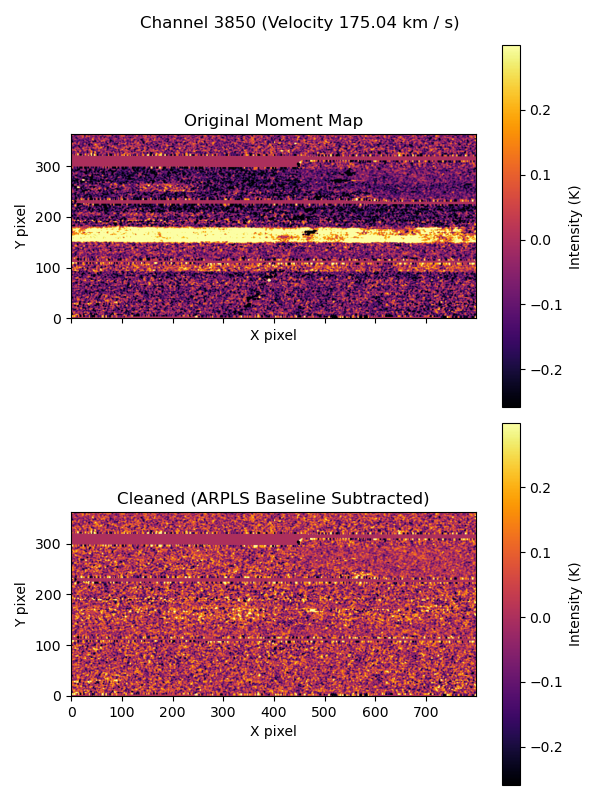

In [12]:
channel = 3850
vel = cube.spectral_axis[channel].to(u.km/u.s)
print(f"Channel {channel} corresponds to velocity {vel:.2f}")

data0 = cube[channel].value
clean0 = corrected_cube[channel].value

vmin, vmax = np.nanpercentile(data0, [5, 95])
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True, sharey=True)
im1 = ax1.imshow(data0,   origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
ax1.set_title('Original Moment Map')
plt.colorbar(im1, ax=ax1, label='Intensity (K)')
im2 = ax2.imshow(clean0,  origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
ax2.set_title('Cleaned (ARPLS Baseline Subtracted)')
plt.colorbar(im2, ax=ax2, label='Intensity (K)')
for ax in (ax1, ax2):
    ax.set_xlabel('X pixel')
    ax.set_ylabel('Y pixel')
plt.suptitle(f"Channel {channel} (Velocity {vel:.2f})")
plt.tight_layout()
plt.show()

In [13]:
pos_cube_slab = corrected_cube.spectral_slab(vmax_global * u.km/u.s, max_v * u.km/u.s)
neg_cube_slab = corrected_cube.spectral_slab(min_v * u.km/u.s, vmin_global * u.km/u.s)
pos_cube_slab, neg_cube_slab

(SpectralCube with shape=(2833, 364, 800):
  n_x:    800  type_x: RA---CAR  unit_x: deg    range:    70.012500 deg:   89.987500 deg
  n_y:    364  type_y: DEC--CAR  unit_y: deg    range:    24.187500 deg:   33.262500 deg
  n_s:   2833  type_s: VRAD      unit_s: m / s  range:    29919.196 m / s:  599954.336 m / s,
 SpectralCube with shape=(2832, 364, 800):
  n_x:    800  type_x: RA---CAR  unit_x: deg    range:    70.012500 deg:   89.987500 deg
  n_y:    364  type_y: DEC--CAR  unit_y: deg    range:    24.187500 deg:   33.262500 deg
  n_s:   2832  type_s: VRAD      unit_s: m / s  range:  -599897.172 m / s:  -30063.315 m / s)

In [14]:
# Save the corrected cube to a new FITS file
pos_cube_slab.write(corrected_file_pos, overwrite=True)
neg_cube_slab.write(corrected_file_neg, overwrite=True)